# 1. Define QUBO matrix

In [16]:
import sys
import numpy as np


sys.path.append("..")
from src.qubo_windfarm_layout.model import get_farm_area, get_mask, build_qubo_from_wake_matrix_optimized, build_wake_loss_matrix_optimized, build_wake_loss_matrix_optimized, load_wake_loss_data
from src.qubo_windfarm_layout.visualization import plot_selected_layout
from src.solvers.utils import get_invalid_pairs
from src.solvers.ortools import solve_wflo_cpsat
from src.solvers.utils import save_benchmark_layout
from src.common.utils import safe_cast_uint16, sparsify_wake_by_percentile

In [28]:
# Variables
GRID_RESOLUTION = 300 # m
MIN_DISTANCE = 396  # 2 * 198 m
SPARSITY = None # percentile di wake interactions da droppare

# Get candidates
polygons, farm_area = get_farm_area()
X, Y, mask = get_mask(farm_area=farm_area, grid_resolution=GRID_RESOLUTION)

candidate_locations = np.column_stack([
    X[mask],
    Y[mask],
])

print(f"Filtered candidates shape {candidate_locations.shape}")

# Invalid pairs constraint
invalid_pairs = get_invalid_pairs(candidate_locations=candidate_locations, min_distance=MIN_DISTANCE)

Filtered candidates shape (401, 2)


In [29]:
# Matrix definition
# build_wake_loss_matrix_optimized(
#     candidate_locations,
#     grid_resolution=GRID_RESOLUTION,
#     output_path=f"../results/precomputed/wake_loss_{GRID_RESOLUTION}m.npz"
# )

wake_loss = load_wake_loss_data(
    f"../results/precomputed/wake_loss_{GRID_RESOLUTION}m.npz"
)

A0 = wake_loss["A0"]

# Quantizzazione 
wake_loss_matrix = safe_cast_uint16(
    wake_loss.pop("wake_loss_matrix")
)

# Libera RAM
del wake_loss
import gc
gc.collect()

Q, offset = build_qubo_from_wake_matrix_optimized(
    wake_loss_matrix,
    invalid_pairs,
    A0,
    n_turbines=81,
    lambda_cardinality=32000,
    lambda_spacing=5500
)

RAM before : 1.23 MB
RAM after  : 0.31 MB
RAM saved  : 0.92 MB (75.0%)


In [ ]:
import numpy as np

A = Q

print("Min:", A.min())
print("Max:", A.max())
print("dtype:", A.dtype)

print("RAM [bytes]:", A.nbytes)
print("RAM [MB]:", A.nbytes / 1024**2)
print("RAM [GB]:", A.nbytes / 1024**3)
print(print(A.dtype))

A = Q.astype(np.uint16)

print("Min:", A.min())
print("Max:", A.max())
print("dtype:", A.dtype)

print("RAM [bytes]:", A.nbytes)
print("RAM [MB]:", A.nbytes / 1024**2)
print("RAM [GB]:", A.nbytes / 1024**3)
print(print(A.dtype))

In [ ]:
if SPARSITY:
    # Sparsifica matrice
    L_sparse, info = sparsify_wake_by_percentile(
    wake_loss_matrix,
    percentile=SPARSITY,
    )

    print(info)
    wake_loss_matrix = L_sparse 
    
    # Libera RAM
    del L_sparse
    import gc
    gc.collect()

    print("Matrice ridotta")

# 2. Solvers

## 2.1 OR Tools - CPSAT

In [ ]:
time_limit_s = 60*30

z_solution, solver = solve_wflo_cpsat(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=time_limit_s,
    num_workers=8,
)

selected_locations = candidate_locations[
    z_solution.astype(bool)
]

plot_selected_layout(selected_locations=selected_locations)

save_benchmark_layout(
    selected_locations=selected_locations,
    solver_name="cpsat",
    filename=f"cpsat_{GRID_RESOLUTION}_{time_limit_s}s.yaml",
    grid_resolution=GRID_RESOLUTION,
    time_limit_s=time_limit_s
)

## 2.2 OR Tools - SCIP

In [ ]:
from src.solvers.ortools import solve_wflo_gscip

time_limit_s = 60*60

z_solution_scip, _ = solve_wflo_gscip(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=time_limit_s,
)

selected_locations_scip = candidate_locations[
    z_solution_scip.astype(bool)
]

plot_selected_layout(selected_locations=selected_locations_scip)

save_benchmark_layout(
    selected_locations=selected_locations_scip,
    solver_name="scip",
    filename=f"scip_{GRID_RESOLUTION}_{time_limit_s}s.yaml",
    grid_resolution=GRID_RESOLUTION,
    time_limit_s=time_limit_s
)

## 2.3 D-Wave Simulated Annealing

In [ ]:
from src.solvers.dwave import solve_wflo_dwave
from src.solvers.utils import save_benchmark_layout

NUM_READS = 1000
NUM_SWEEPS = 40000

z_dwave, sampleset = solve_wflo_dwave(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    Q=Q,
    n_turbines=81,
    sampler_type="simulated_annealing",
    num_reads=NUM_READS,   # Dimezzare read e quadruplicare sweep costa lo stesso tempo
    num_sweeps=NUM_SWEEPS, # num_sweeps >= 10 x n variables
    seed=42,
)
selected_locations_dwave = candidate_locations[z_dwave.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_dwave)
save_benchmark_layout(
    selected_locations=selected_locations_dwave,
    solver_name="dwave_sa",
    filename=f"dwave_sa_{GRID_RESOLUTION}_{NUM_READS}reads_{NUM_SWEEPS}sweeps.yaml",
    grid_resolution=GRID_RESOLUTION,
)

In [ ]:
f"dwave_sa_{GRID_RESOLUTION}_{NUM_READS}reads_{NUM_SWEEPS}sweeps.yaml"

## 2.4 SQBM+

In [12]:
from src.solvers.sqbm import SQBMClient, solve_wflo_sqbm, solve_wflo_sqbm_qplib

SQBM_HOST = "20.229.234.199"
SQBM_PORT = 8000

client = SQBMClient(host=SQBM_HOST, port=SQBM_PORT, timeout=1200, problem_format="hdf5")

print("Health check:", client.health_check())
print("Version:     ", client.version())

Health check: True
Version:      2.1.3


### 2.4.1 QUBO Solver

In [30]:
TIMEOUT = 60
ALGO = 0

solution, sqbm_result = solve_wflo_sqbm(
    wake_loss_matrix,
    invalid_pairs,
    Q,
    host=SQBM_HOST,
    port=SQBM_PORT,
    timeout=TIMEOUT,
    algo=ALGO,
)
selected_locations_sqbm = candidate_locations[solution.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_sqbm)
save_benchmark_layout(
    selected_locations=selected_locations_sqbm,
    solver_name="sqbm",
    filename=f"sqbm_{GRID_RESOLUTION}_{ALGO}algo_{TIMEOUT}s.yaml",
    grid_resolution=GRID_RESOLUTION,
)

n = 401 variabili, SQBM+ @ 20.229.234.199:8000 (hdf5)


KeyboardInterrupt: 

### 2.4.1 QPLIB Solver

In [31]:
TIMEOUT = 10
ALGO = 0
METHOD = "qplib"


solution, result = solve_wflo_sqbm_qplib(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    host=SQBM_HOST,
    port=SQBM_PORT,

    # Wake matrix quasi densa -> dense è sensato.
    # Constraint matrix -> fortemente sparsa.
    q_format="dense",
    a_format="csr",

    http_timeout=1300,
    timeout=TIMEOUT,

    algo=ALGO,

    # qplib-specific, opzionali
    pd3o_rate=None,
    phi=None,
    detail_level=1,
    detail_log=None,
)

n = 401 variabili, 670 spacing constraints, SQBM+ QPLIB @ 20.229.234.199:8000 (Q=dense, A=csr)
QPLIB completato in 12.7s  (server: 10.0s)
Turbine selezionate: 81
Spacing violations: 0
Pairwise wake loss: 1112976.0000
SQBM+ objective: 1112976.0000


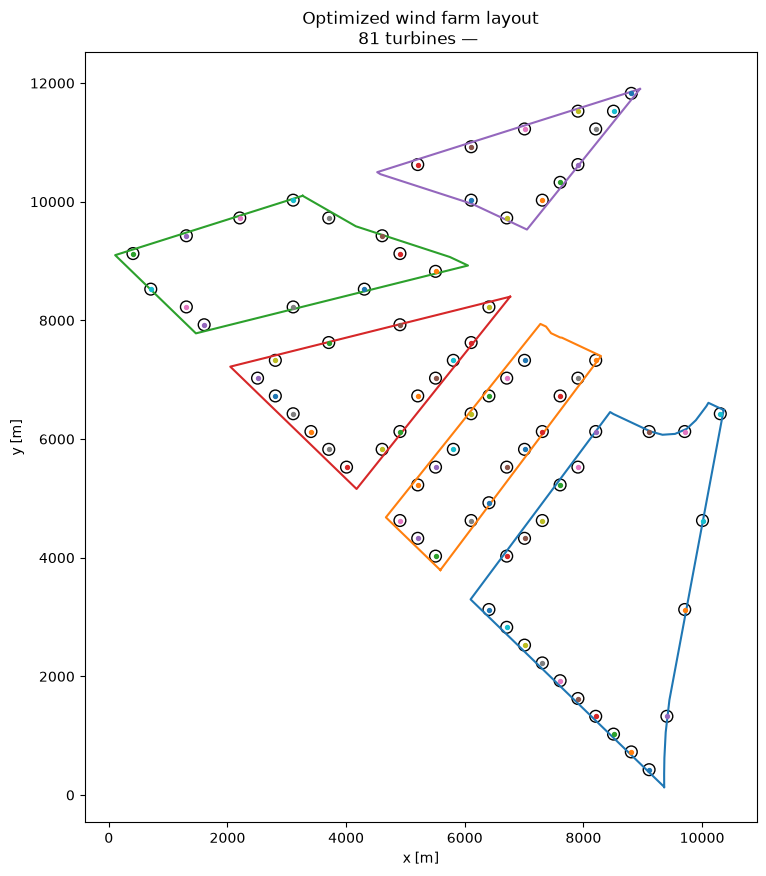

Layout saved to: /home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/sqbm_qplib_300_0algo_10s.yaml


PosixPath('/home/maicolnicolini/code/qubo-wind-farm-layout/notebooks/../results/layouts/sqbm_qplib_300_0algo_10s.yaml')

In [32]:
selected_locations_sqbm = candidate_locations[solution.astype(bool)]
plot_selected_layout(selected_locations=selected_locations_sqbm)
save_benchmark_layout(
    selected_locations=selected_locations_sqbm,
    solver_name="sqbm",
    filename=f"sqbm_{METHOD}_{GRID_RESOLUTION}_{ALGO}algo_{TIMEOUT}s.yaml",
    grid_resolution=GRID_RESOLUTION,
)

## 2.5 Gurobi

In [ ]:
from src.qubo_windfarm_layout.penalties import layout_yaml_to_z
from src.solvers.gurobi import solve_wflo_gurobi

TIMEOUT = 60 * 30
WARMSTART = False

result = solve_wflo_gurobi(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    warm_start=WARMSTART,
    time_limit=TIMEOUT,
    mip_gap=0.01,
)

print("Objective:", result["objective"])
print("Runtime:", result["runtime"])
print("MIP gap:", result["mip_gap"])
print("Best bound:", result["best_bound"])
print("N turbines:", result["z"].sum())

selected_indices = result["selected_indices"]
selected_locations_gurobi = candidate_locations[
    selected_indices
]

plot_selected_layout(selected_locations=selected_locations_gurobi)
save_benchmark_layout(
    selected_locations=selected_locations_gurobi,
    solver_name="gurobi",
    filename=f"gurobi_{GRID_RESOLUTION}_{TIMEOUT}s_warmstart_{WARMSTART}.yaml",
    grid_resolution=GRID_RESOLUTION,
)

In [ ]:
from src.qubo_windfarm_layout.penalties import layout_yaml_to_z

GRID_RESOLUTION = 75

z_reference_up, candidate_locations = layout_yaml_to_z(
    yaml_path="/home/maicolnicolini/code/qubo-wind-farm-layout/src/../results/layouts/gurobi_75_3600s_warmstart_None.yaml",
    grid_resolution = GRID_RESOLUTION
    )

L = np.asarray(wake_loss_matrix, dtype=float)
x = np.asarray(z_reference_up, dtype=float)

# H_wake = sum_{i<j} L_ij x_i x_j
# L è simmetrica, quindi dividiamo per 2
Q = L / 2

upper_bound = float(x @ Q @ x)
print(upper_bound)

# Solvers

| Categoria                        | Solver                       |
| -------------------------------- | ---------------------------- |
| Exact / mathematical programming | **Gurobi**                   |
| CP/SAT                           | **OR-Tools CP-SAT**          |
| SCIP                             | **OR-Tools GSCIP**           |
| HiGHS                            | **OR-Tools HiGHS**           |
| Classical hybrid heuristic       | **Hexaly**                   |
| QUBO classical baseline          | **Simulated Annealing**      |
| QUBO classical baseline          | **D-Wave Tabu**              |
| Quantum-inspired                 | **Toshiba SQBM+**            |
| Quantum-inspired                 | **Fujitsu Digital Annealer** |

In [ ]:
# TODO
# Capire se usare base.yaml come starting point (warmstart) può creare dei vantaggi per i solutori quantum